# **HW02 - Разведочный анализ данных(EDA)**

### Анализ данных о симптомах сердечно-сосудистых заболеваний.
Данные: https://github.com/msamhz/GA-Lessons/blob/main/2.04-lesson-eda/datasets/Heart.csv

Age       --    Возраст\
Sex       --    Пол\
ChestPain --    Боль в груди\
RestBP    --    Давление в спокойном состоянии\
Chol      --    Уровень холестерола\
Fbs       --    Уровень сахара в крови\
RestECG   --    Кардиограмма в спокойном состоянии\
MaxHR     --    Максимальная частота сердечных сокращений\
ExAng     --    Стенокардия\
Oldpeak   --    Смещение ST сегмента на кардиограмме\
Slope     --    Наклон ST сегмента на кардиограмме\
Ca        --    Количество поражённых атеросклерозом сосудов\
Thal      --    Результаты теста на ишемию\
AHD       --    Target

### 1. Загрузка библиотек

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import plotly
import matplotlib.pyplot as plt

Загрузка кодировщиков категориальных признаков.

In [2]:
from category_encoders import HashingEncoder
from sklearn.preprocessing import OneHotEncoder

Загрузка модели для итоговой оценки важности признаков.

In [3]:
from sklearn.ensemble import RandomForestClassifier

### 2. Загрузка и быстрый обзор данных

In [4]:
df=pd.read_csv('Heart.csv')

In [5]:
df.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,0
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,1
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,1
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,0
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,0


In [6]:
df.tail()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
298,299,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,1
299,300,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,1
300,301,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,1
301,302,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,1
302,303,38,1,nonanginal,138,175,0,0,173,0,0.0,1,NaN,normal,0


In [7]:
df.shape

(303, 15)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   Age         303 non-null    str    
 2   Sex         303 non-null    int64  
 3   ChestPain   303 non-null    str    
 4   RestBP      303 non-null    int64  
 5   Chol        303 non-null    int64  
 6   Fbs         303 non-null    int64  
 7   RestECG     303 non-null    int64  
 8   MaxHR       303 non-null    int64  
 9   ExAng       303 non-null    int64  
 10  Oldpeak     303 non-null    float64
 11  Slope       303 non-null    int64  
 12  Ca          299 non-null    float64
 13  Thal        301 non-null    str    
 14  AHD         303 non-null    int64  
dtypes: float64(2), int64(10), str(3)
memory usage: 35.6 KB


Возраст не имеет смысла представлять строковым типом, необходимо проверить данные в этом столбце на адекватность и преобразовать в численный тип.

In [9]:
df.Age.unique()

<StringArray>
['63', '67', '37', '41', '56', '62', '57', '53', '44', '52', '48', '54', '49',
 '64', '58', '60', '50',  '?', '66', '43', '40', '69', '59', '42', '55', '61',
 '65', '71', '51', '46', '45', '39', '68', '47', '34', '35', '29', '70', '77',
 '38', '74', '76']
Length: 42, dtype: str

In [10]:
df["Age"]=pd.to_numeric(df["Age"], errors="coerce")

In [11]:
df.Age.dtype

dtype('float64')

Изменён тип данных для возраста.

In [12]:
df.describe()

,Unnamed: 0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD
count,303.000000,294.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,303.000000
mean,152.000000,54.357143,0.679868,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,0.458746
std,87.612784,9.124004,0.467299,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,0.499120
min,1.000000,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,76.500000,47.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,152.000000,55.000000,1.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,0.000000
75%,227.500000,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,1.000000
max,303.000000,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000


In [13]:
df.describe(include=object)

/tmp/ipykernel_16526/3998025828.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=object)


,ChestPain,Thal
count,303,301
unique,4,3
top,asymptomatic,normal
freq,144,166


### 3. Обработка пропусков

In [14]:
df.isnull().sum()

Unnamed: 0    0
Age           9
Sex           0
ChestPain     0
RestBP        0
Chol          0
Fbs           0
RestECG       0
MaxHR         0
ExAng         0
Oldpeak       0
Slope         0
Ca            4
Thal          2
AHD           0
dtype: int64

В датасете есть колонки с пропущенными значениями: возраст(Age), ca(Ca), thallium stress test(Thal). \
ca - количество основных сосудов, поражённых атеросклерозом(из 3х). \
thallium stress test - результаты теста на ишемию.

In [15]:
df["Age"].describe()

count    294.000000
mean      54.357143
std        9.124004
min       29.000000
25%       47.000000
50%       55.000000
75%       61.000000
max       77.000000
Name: Age, dtype: float64

Так как среднее значение и медиана совпадают, то заполним пропуски в колонке возраста средним значением.

In [16]:
average_age=df.Age.mean()

In [17]:
df["Age"]=df["Age"].fillna(average_age)

In [18]:
df.Ca.describe()

count    299.000000
mean       0.672241
std        0.937438
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        3.000000
Name: Ca, dtype: float64

Проверки влияния наличия значения в столбце Ca на целевую переменную.

In [19]:
df["Diagnosis_binary"] = (df["AHD"] > 0).astype(int)

In [20]:
missing_by_diagnosis = df.groupby('Diagnosis_binary')['Ca'].apply(lambda x: x.isnull().sum())
missing_by_diagnosis

Diagnosis_binary
0    3
1    1
Name: Ca, dtype: int64

In [21]:
df.groupby('Ca').AHD.mean()

Ca
0.0    0.261364
1.0    0.676923
2.0    0.815789
3.0    0.850000
Name: AHD, dtype: float64

Следовательно, отсутствие значения чаще встречается у здоровых людей. Заменим пропуски нулём, так как именно при этом значении вероятность сердечных заболеваний минимальна.

In [22]:
df['Ca']=df['Ca'].fillna(0)

In [23]:
df.groupby('Thal').AHD.mean()

Thal
fixed         0.666667
normal        0.222892
reversable    0.760684
Name: AHD, dtype: float64

In [24]:
df.Thal.mode()

0    normal
Name: Thal, dtype: str

In [25]:
missing_by_diagnosis = df.groupby('Diagnosis_binary')['Thal'].apply(lambda x: x.isnull().sum())
missing_by_diagnosis

Diagnosis_binary
0    1
1    1
Name: Thal, dtype: int64

Так как в случае колонки Thal нельзя сказать влияет ли наличие записи на постановку диагноза, исключим строки с пропуском записи в данной колонке.

In [26]:
df=df.dropna()

In [27]:
df.info()

<class 'pandas.DataFrame'>
Index: 301 entries, 0 to 302
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        301 non-null    int64  
 1   Age               301 non-null    float64
 2   Sex               301 non-null    int64  
 3   ChestPain         301 non-null    str    
 4   RestBP            301 non-null    int64  
 5   Chol              301 non-null    int64  
 6   Fbs               301 non-null    int64  
 7   RestECG           301 non-null    int64  
 8   MaxHR             301 non-null    int64  
 9   ExAng             301 non-null    int64  
 10  Oldpeak           301 non-null    float64
 11  Slope             301 non-null    int64  
 12  Ca                301 non-null    float64
 13  Thal              301 non-null    str    
 14  AHD               301 non-null    int64  
 15  Diagnosis_binary  301 non-null    int64  
dtypes: float64(3), int64(11), str(2)
memory usage: 40.0 KB


### Пропуски обработаны.

### 4.Вычисление числовых характеристик данных

In [28]:
df.describe()

,Unnamed: 0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,Diagnosis_binary
count,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000,301.000000
mean,151.830565,54.369483,0.681063,131.714286,246.936877,0.146179,0.990033,149.700997,0.325581,1.043189,1.601329,0.667774,0.458472,0.458472
std,87.575156,9.015553,0.466841,17.655729,51.859869,0.353874,0.994937,22.860817,0.469372,1.163384,0.616872,0.935908,0.499102,0.499102
min,1.000000,29.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,76.000000,48.000000,0.000000,120.000000,211.000000,0.000000,0.000000,134.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
50%,152.000000,55.000000,1.000000,130.000000,242.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,0.000000,0.000000
75%,227.000000,61.000000,1.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,1.000000,1.000000
max,303.000000,77.000000,1.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,1.000000,1.000000


Проверим, есть ли среди выведенных признаков категориальные, закодированные как числовые.

In [29]:
df.nunique()

Unnamed: 0          301
Age                  42
Sex                   2
ChestPain             4
RestBP               50
Chol                152
Fbs                   2
RestECG               3
MaxHR                91
ExAng                 2
Oldpeak              40
Slope                 3
Ca                    4
Thal                  3
AHD                   2
Diagnosis_binary      2
dtype: int64

К таким можно отнести Sex, Fbs, RestEGG, ExAng, Slope, Ca.

In [30]:
df.Sex.unique()

array([1, 0])

In [31]:
df.Fbs.unique()

array([1, 0])

In [32]:
df.ExAng.unique()

array([0, 1])

Причём для бинарных признаков(Sex, Fbs, ExAng) значение mean будет говорить о процентном соотнощении людей с данным признаком относительно всей выборки.\
Тогда соответственно:\
Sex - 68% \
Fbs - 14% \
ExAng - 32%

В таком случае необходимо проверить, насколько сильно наличие данных признаков у пациента связано с наличием заболевания.

In [33]:
df.groupby('Sex').AHD.mean()

Sex
0    0.260417
1    0.551220
Name: AHD, dtype: float64

In [34]:
df.groupby('Fbs').AHD.mean()

Fbs
0    0.455253
1    0.477273
Name: AHD, dtype: float64

In [35]:
df.groupby('ExAng').AHD.mean()

ExAng
0    0.310345
1    0.765306
Name: AHD, dtype: float64

Наличие 1 в значении признаков Sex, ExAng в значительной степени влияют на наличие заболевания.

Перейдём к анализу небинарных признаков - RestEcg, Slope, Ca.

In [36]:
df.groupby('RestECG').AHD.count()

RestECG
0    150
1      4
2    147
Name: AHD, dtype: int64

In [37]:
df.groupby(['RestECG', 'AHD']).Diagnosis_binary.sum()

RestECG  AHD
0        0       0
         1      55
1        0       0
         1       3
2        0       0
         1      80
Name: Diagnosis_binary, dtype: int64

RestECG: вероятность заболевания в зависимости от группы: \
1:  36% \
2:  75% \
3:  54%

In [38]:
df.groupby('Slope').AHD.count()

Slope
1    141
2    139
3     21
Name: AHD, dtype: int64

In [39]:
df.groupby(['Slope', 'AHD']).Diagnosis_binary.sum()

Slope  AHD
1      0       0
       1      36
2      0       0
       1      90
3      0       0
       1      12
Name: Diagnosis_binary, dtype: int64

Slope: вероятность заболевания в зависимости от группы: \
1:  25% \
2:  65% \
3:  57%

In [40]:
df.groupby('Ca').AHD.count()

Ca
0.0    178
1.0     65
2.0     38
3.0     20
Name: AHD, dtype: int64

In [41]:
df.groupby(['Ca', 'AHD']).Diagnosis_binary.sum()

Ca   AHD
0.0  0       0
     1      46
1.0  0       0
     1      44
2.0  0       0
     1      31
3.0  0       0
     1      17
Name: Diagnosis_binary, dtype: int64

Ca: вероятность заболевания в зависимости от значения признака:
0:  25% \
1:  68% \
2:  81% \
3:  85% 

С ростом числового значения значительно возрастает шанс наличия заболевания у пациента.

Перейдём к анализу continious признаков.

In [42]:
df.Age.describe()

count    301.000000
mean      54.369483
std        9.015553
min       29.000000
25%       48.000000
50%       55.000000
75%       61.000000
max       77.000000
Name: Age, dtype: float64

In [43]:
print(df.Age.var())
print(df.Age.skew())
print(df.Age.kurtosis())

81.28018735733497
-0.19554996933628496
-0.4939905542591103


Age: дисперсия велика, данные распределены равонмерно, нет преобладания конкретной возрастной категории.

In [44]:
df.RestBP.describe()

count    301.000000
mean     131.714286
std       17.655729
min       94.000000
25%      120.000000
50%      130.000000
75%      140.000000
max      200.000000
Name: RestBP, dtype: float64

In [45]:
print(df.RestBP.var())
print(df.RestBP.skew())
print(df.RestBP.kurtosis())

311.72476190476186
0.6999009736831802
0.8528049005695011


RestBP: дисперсия велика отностительно значений признака, значения преимущественно лежат в промежутке 120-140.

In [46]:
df.Chol.describe()

count    301.000000
mean     246.936877
std       51.859869
min      126.000000
25%      211.000000
50%      242.000000
75%      275.000000
max      564.000000
Name: Chol, dtype: float64

In [47]:
print(df.Chol.var())
print(df.Chol.skew())
print(df.Chol.kurtosis())

2689.4460022148387
1.1260166138465035
4.470760746782681


Chol: большинсво значений сконцентрированы в промежутке 210-275, однако есть выбросы (max=564). \
Хвост смещён вправо(высокий эксцесс)

In [48]:
df.MaxHR.describe()

count    301.000000
mean     149.700997
std       22.860817
min       71.000000
25%      134.000000
50%      153.000000
75%      166.000000
max      202.000000
Name: MaxHR, dtype: float64

MaxHR: большинсво значений лежат в промежутке 135-166.

In [49]:
print(df.MaxHR.var())
print(df.MaxHR.skew())
print(df.MaxHR.kurtosis())

522.6169656699889
-0.542878731121084
-0.03501702575701504


In [50]:
df.Oldpeak.describe()

count    301.000000
mean       1.043189
std        1.163384
min        0.000000
25%        0.000000
50%        0.800000
75%        1.600000
max        6.200000
Name: Oldpeak, dtype: float64

In [51]:
print(df.Oldpeak.var())
print(df.Oldpeak.skew())
print(df.Oldpeak.kurtosis())

1.3534617940199334
1.2637332963359913
1.5522161434201944


Oldpeak: выраженная правосторонняя асимметрия.

Рассмотрим категориальные признаки со строковым значением.

In [52]:
df.ChestPain.mode()

0    asymptomatic
Name: ChestPain, dtype: str

In [53]:
df[df.AHD==1].groupby('ChestPain').Diagnosis_binary.count()

ChestPain
asymptomatic    104
nonanginal       18
nontypical        9
typical           7
Name: Diagnosis_binary, dtype: int64

In [54]:
df.groupby('ChestPain').count()

,Unnamed: 0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD,Diagnosis_binary
ChestPain,,,,,,,,,,,,,,,
asymptomatic,143,143,143,143,143,143,143,143,143,143,143,143,143,143,143
nonanginal,85,85,85,85,85,85,85,85,85,85,85,85,85,85,85
nontypical,50,50,50,50,50,50,50,50,50,50,50,50,50,50,50
typical,23,23,23,23,23,23,23,23,23,23,23,23,23,23,23


ChestPain: вероятность заболевания по категориям: \
asymptomatic:  72% \
nonanginal:  21% \
nontypical:  18% \
typical:  30% 

Отсутствие симптомов(asymptomatic) значительно повышает риск наличия заболевания.

In [55]:
df.Thal.mode()

0    normal
Name: Thal, dtype: str

In [56]:
df[df.AHD==1].groupby('Thal').Diagnosis_binary.count()

Thal
fixed         12
normal        37
reversable    89
Name: Diagnosis_binary, dtype: int64

In [57]:
df.groupby('Thal').count()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,Diagnosis_binary
Thal,,,,,,,,,,,,,,,
fixed,18,18,18,18,18,18,18,18,18,18,18,18,18,18,18
normal,166,166,166,166,166,166,166,166,166,166,166,166,166,166,166
reversable,117,117,117,117,117,117,117,117,117,117,117,117,117,117,117


Thal: вероятность заболевания: \
fixed:  67% \
normal:  22% \
reversable:  76% 

In [58]:
df.groupby('Diagnosis_binary').mean(numeric_only=True).T

Diagnosis_binary,0,1
Unnamed: 0,148.441718,155.833333
Age,52.493427,56.585404
Sex,0.564417,0.818841
RestBP,129.257669,134.615942
Chol,242.803681,251.818841
Fbs,0.141104,0.152174
RestECG,0.828221,1.181159
MaxHR,158.644172,139.137681
ExAng,0.141104,0.543478
Oldpeak,0.590184,1.578261


Столбцы со значительной разницей в значениях признака для больных и здоровых: \
Oldpeak(0.59 & 1.58), \
Ca(0.26 & 1.14) \
ExAng(0.14 & 0.54) \
RestECg(0.82 & 1.18) \
Sex(0.56 & 0.81) 

### 5.Фичи. Encoding & Engeneering

Сначала закодируем признаки со строковым значением: ChestPain, Thal.

In [59]:
print(df.ChestPain.unique())
print(df.Thal.unique())

<StringArray>
['typical', 'asymptomatic', 'nonanginal', 'nontypical']
Length: 4, dtype: str
<StringArray>
['fixed', 'normal', 'reversable']
Length: 3, dtype: str


Для признака ChestPain применим OneHot Encoder так как выделение отдельного столбца для asymptomatic категории приведёт к получению одного из ключевых маркеров наличия заболевания. \
Для признака Thal применим Feature Hashing для уменьшения количесвта выходных колонок до 2х, можно было бы также использовать и OneHot Encoder, но мне интересно, как наботает Feature Hashing.

In [60]:
df = pd.get_dummies(df, columns=['ChestPain'], drop_first=True)

In [61]:
he = HashingEncoder(cols=['Thal'], n_components=3)
hash_results = he.fit_transform(df['Thal'])
hash_results=hash_results.rename(columns={'col_0':'Thal_0', 'col_1':'Thal_1', 'col_2':'Thal_2'})
df=pd.concat([df, hash_results], axis=1)

Количество колонок, добавленных feature hashing == 3, так как при 2х получаем коллизии, а при наличии 3х уникальных значений коллизии будут сильно сказываться на результате. Так что в данном случае получаем аналог OneHot Encoding.

In [62]:
df=df.drop('Thal', axis=1)

Проверим корреляцию признаковю

In [63]:
df.corr()

,Unnamed: 0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,AHD,Diagnosis_binary,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_0,Thal_1,Thal_2
Unnamed: 0,1.000000,0.001629,-0.077966,-0.021706,-0.093872,-0.051580,-0.144475,-0.111207,-0.008385,-0.123019,-0.033833,0.038597,0.042126,0.042126,-0.089359,0.070803,-0.015034,-0.058479,0.063149,0.027210
Age,0.001629,1.000000,-0.098682,0.283960,0.200582,0.118168,0.147438,-0.398744,0.100438,0.196672,0.162759,0.347257,0.226532,0.226532,-0.055505,-0.152494,0.041488,0.100105,0.064368,-0.128804
Sex,-0.077966,-0.098682,1.000000,-0.065284,-0.202126,0.041025,0.029016,-0.057065,0.140802,0.098482,0.031571,0.084732,0.272006,0.272006,-0.109109,-0.039324,0.089502,0.326333,0.142522,-0.387797
RestBP,-0.021706,0.283960,-0.065284,1.000000,0.129371,0.178498,0.147089,-0.046402,0.065564,0.188801,0.117437,0.096713,0.151471,0.151471,-0.049705,-0.083922,0.149400,0.105339,0.074833,-0.138923
Chol,-0.093872,0.200582,-0.202126,0.129371,1.000000,0.015762,0.171185,-0.005690,0.064250,0.044836,-0.004228,0.120782,0.086762,0.086762,-0.032021,-0.018594,-0.054481,0.049548,-0.097116,-0.002261
Fbs,-0.051580,0.118168,0.041025,0.178498,0.015762,1.000000,0.079892,-0.012297,0.013534,0.004855,0.054079,0.147124,0.015613,0.015613,0.095566,-0.058340,0.057979,0.036597,0.093944,-0.080659
RestECG,-0.144475,0.147438,0.029016,0.147089,0.171185,0.079892,1.000000,-0.077950,0.092626,0.117580,0.140144,0.132462,0.177049,0.177049,-0.097726,-0.103363,0.065838,0.008001,0.044848,-0.029225
MaxHR,-0.111207,-0.398744,-0.057065,-0.046402,-0.005690,-0.012297,-0.077950,1.000000,-0.386043,-0.349391,-0.393527,-0.270133,-0.425870,-0.425870,0.169902,0.248732,0.078838,-0.218899,-0.161223,0.291414
ExAng,-0.008385,0.100438,0.140802,0.065564,0.064250,0.013534,0.092626,-0.386043,1.000000,0.287926,0.254076,0.148407,0.427860,0.427860,-0.262615,-0.233910,-0.093098,0.304085,0.063973,-0.328541
Oldpeak,-0.123019,0.196672,0.098482,0.188801,0.044836,0.004855,0.117580,-0.349391,0.287926,1.000000,0.576795,0.299771,0.423894,0.423894,-0.122453,-0.279444,0.086211,0.300722,0.104018,-0.344337


Построим тепловую карту матрицы корреляций.

<Axes: >

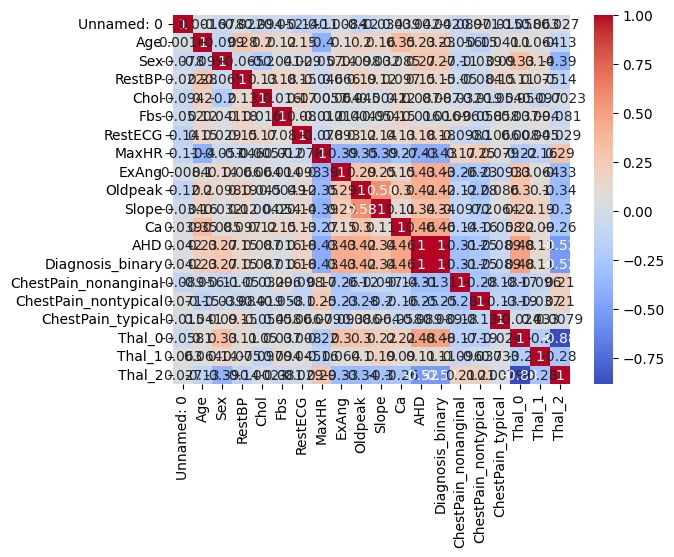

In [64]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

### 6. Графики и распределения

In [65]:
def plot_outliers(df, column):
    """Визуализирует распределение и выбросы"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Box plot
    sns.boxplot(y=df[column], ax=axes[0])
    axes[0].set_title(f'Box plot - {column}')
    
    # Histogram
    sns.histplot(df[column], bins=30, ax=axes[1])
    axes[1].set_title(f'Histogram - {column}')
    
    # Scatter plot with index
    axes[2].scatter(range(len(df)), df[column])
    axes[2].set_title(f'Scatter plot - {column}')
    axes[2].set_xlabel('Index')
    
    plt.tight_layout()
    plt.show()

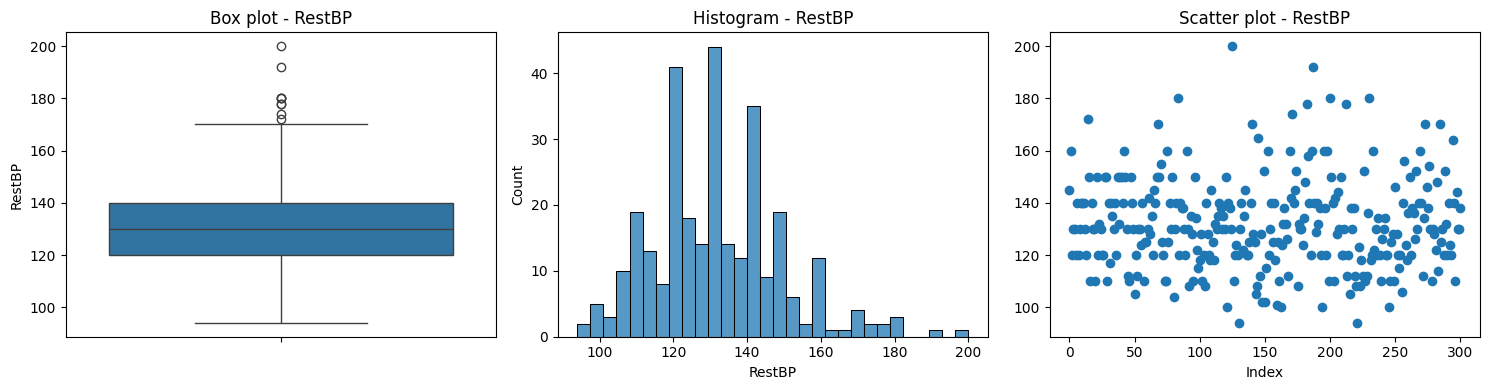

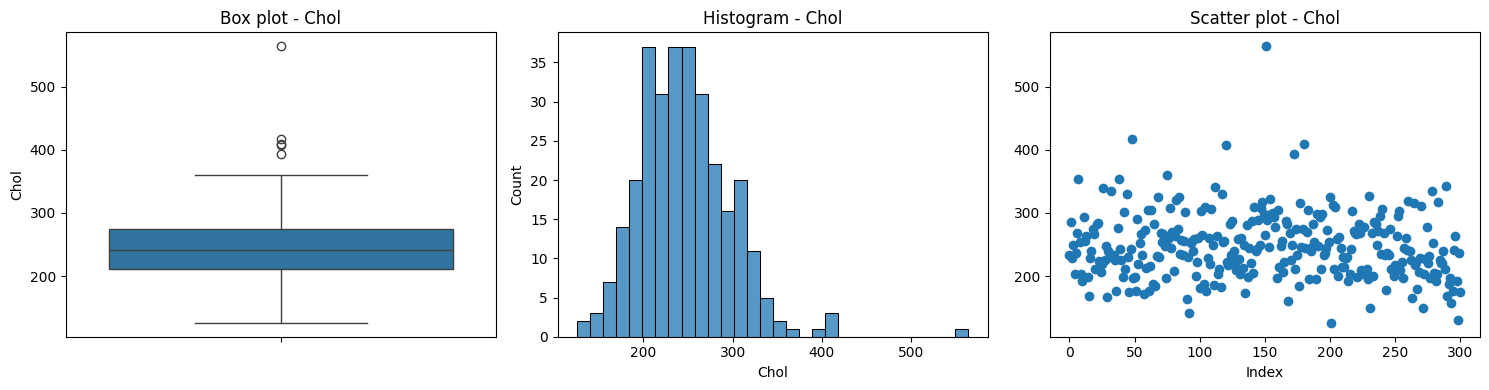

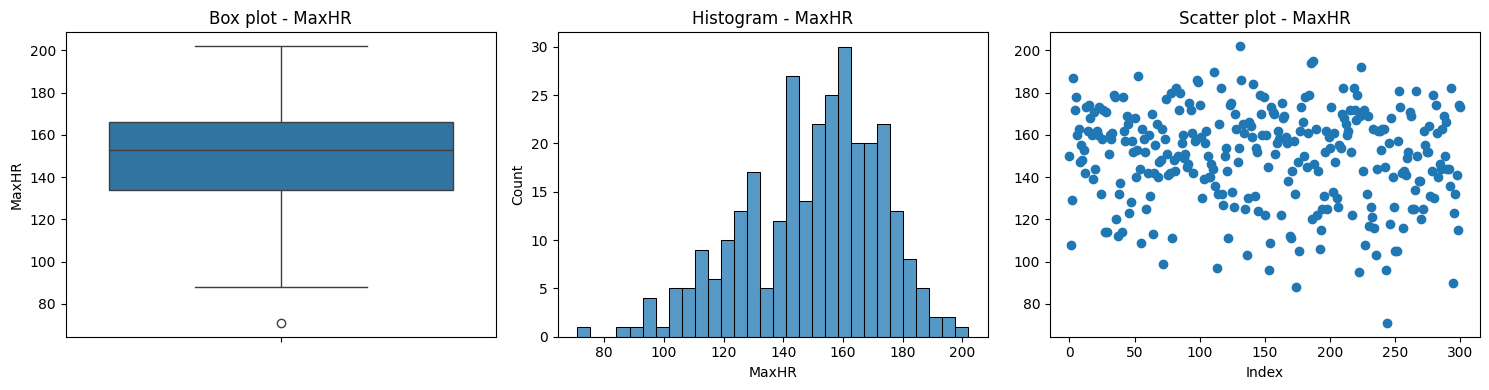

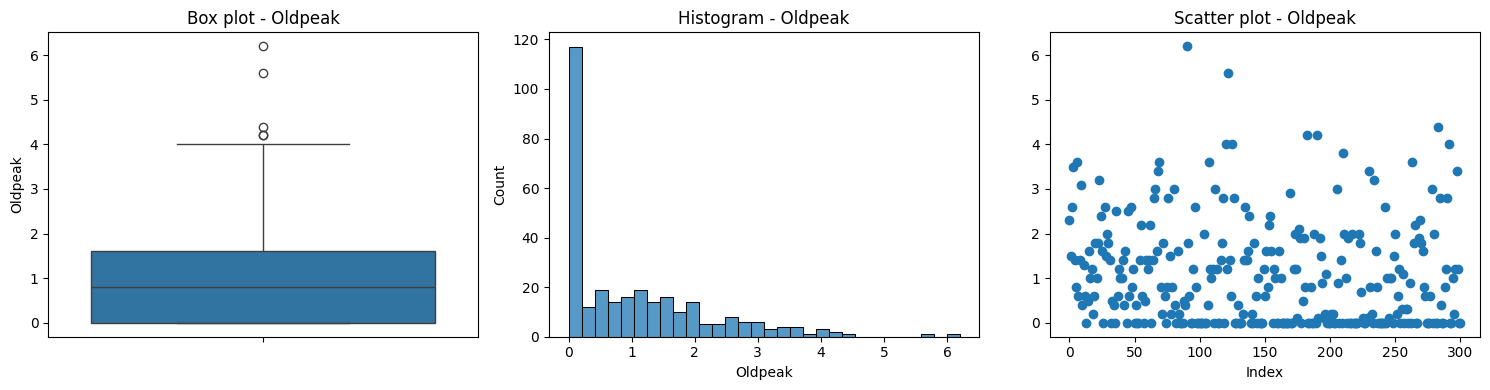

In [66]:
columns_to_remove_outliers = df[['RestBP', 'Chol', 'MaxHR', 'Oldpeak']]
for col in columns_to_remove_outliers:
    plot_outliers(df, col)

Убираем выбросы для RestBP, Chol, MaxHR, Oldpeak.

In [67]:
def remove_outliers_iqr(df, column, multiplier=1.5):
    
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    
    df_filtered = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    
    print(f"Удалено строк: {len(df) - len(df_filtered)}")
    print(f"Границы: [{lower_bound:.2f}, {upper_bound:.2f}]")
    
    return df_filtered

Удалено строк: 9
Границы: [90.00, 170.00]


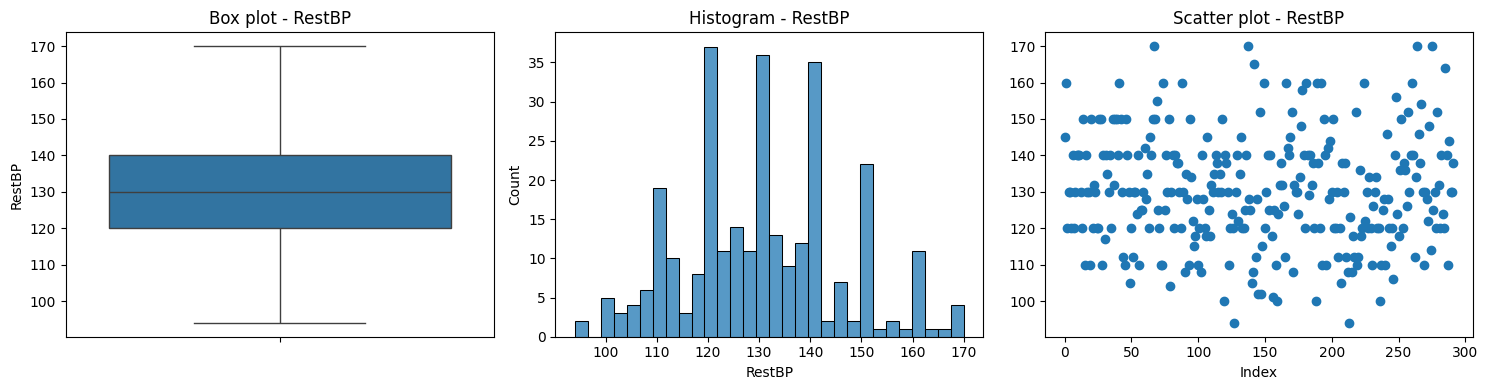

Удалено строк: 5
Границы: [116.12, 369.12]


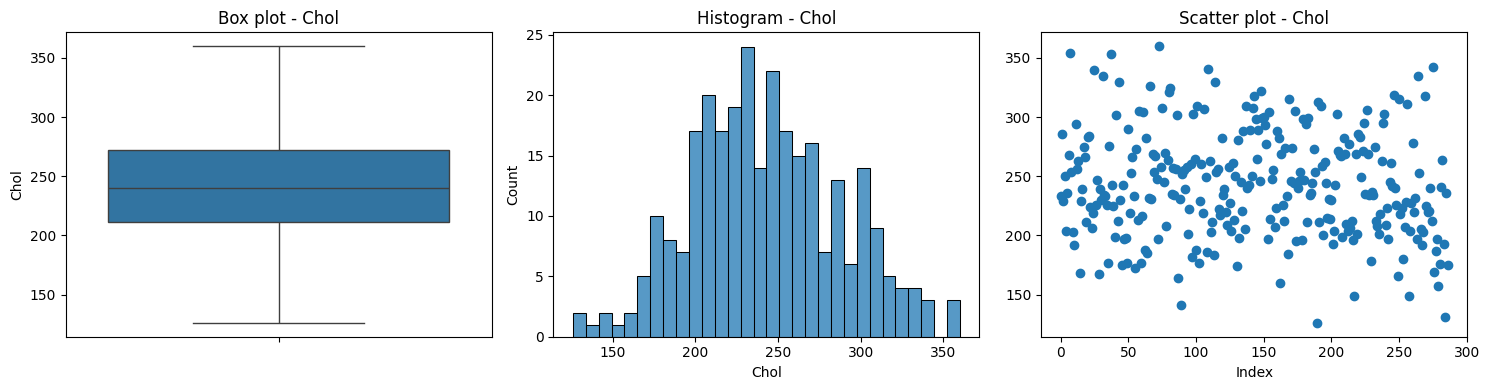

Удалено строк: 1
Границы: [80.00, 220.00]


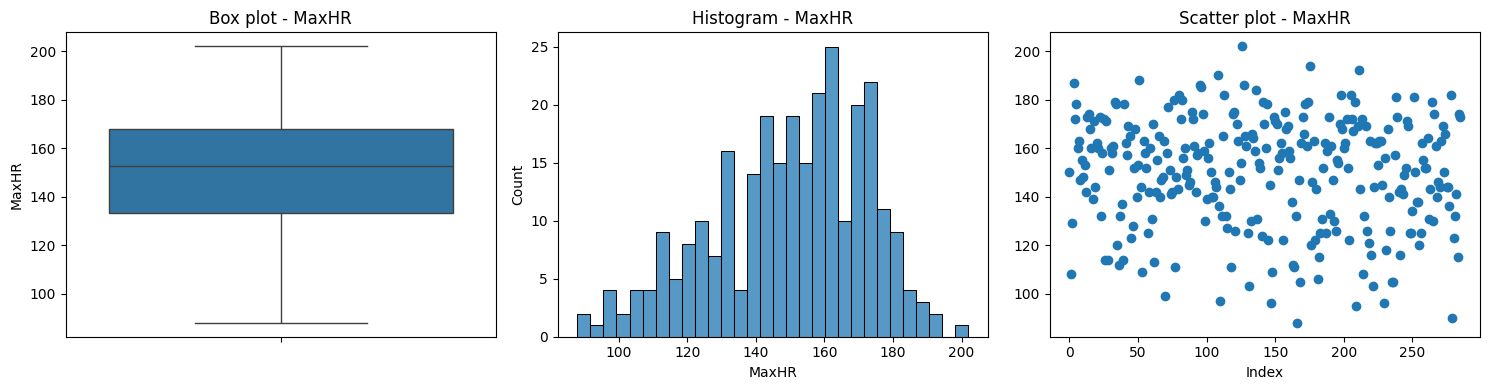

Удалено строк: 4
Границы: [-2.40, 4.00]


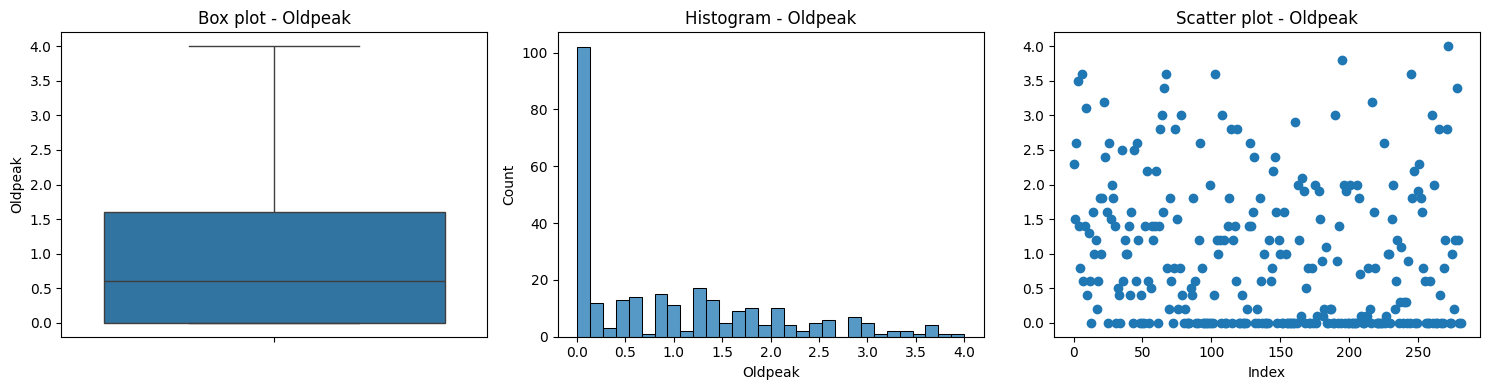

In [68]:
columns_to_remove_outliers = df[['RestBP', 'Chol', 'MaxHR', 'Oldpeak']]
for col in columns_to_remove_outliers:
    df=remove_outliers_iqr(df, col, 1.5)
    plot_outliers(df, col)

Посмотрим на распределение категориальных признаков.

In [69]:
def plot_cat_distributions(df, column):

    fig, axes = plt.subplots(1, 2, figsize=(20, 4))
    
    # Point plot
    sns.pointplot(data=df, x=column, y="AHD", ax=axes[0])
    axes[0].set_title(f'Probability of AHD by {column}')
    axes[0].set_ylabel('P(AHD=1)')
    
    # Count plot
    sns.countplot(data=df, x=column, hue="AHD", ax=axes[1])
    axes[1].set_title(f'Count plot - {column} by AHD')
    
    plt.tight_layout()
    plt.show()

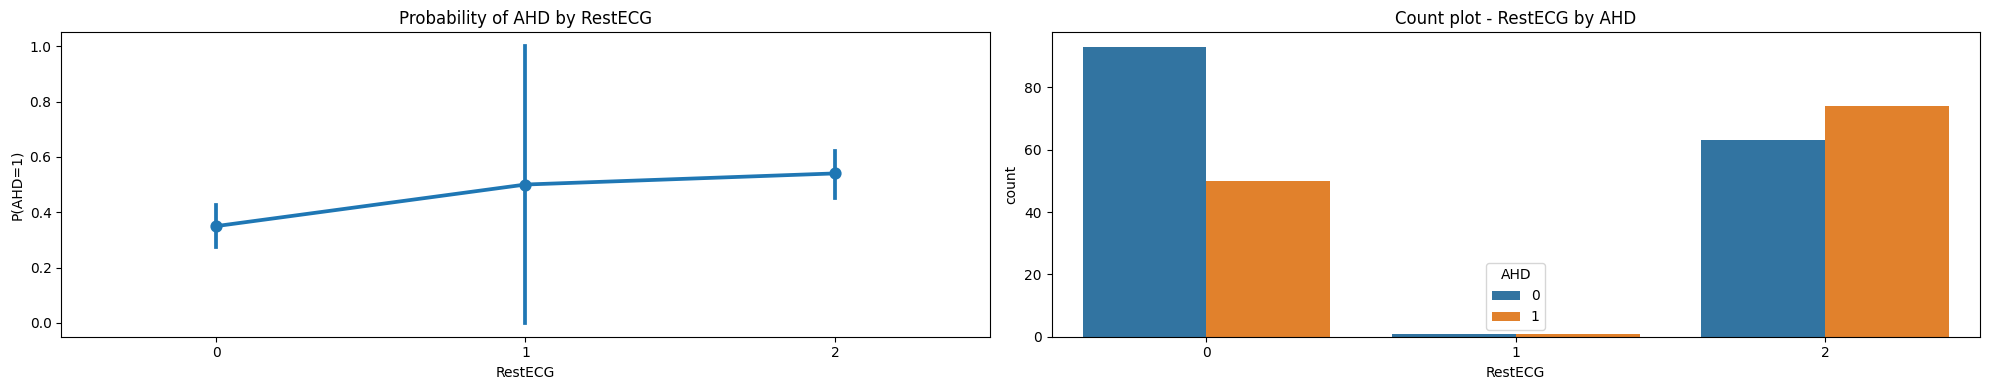

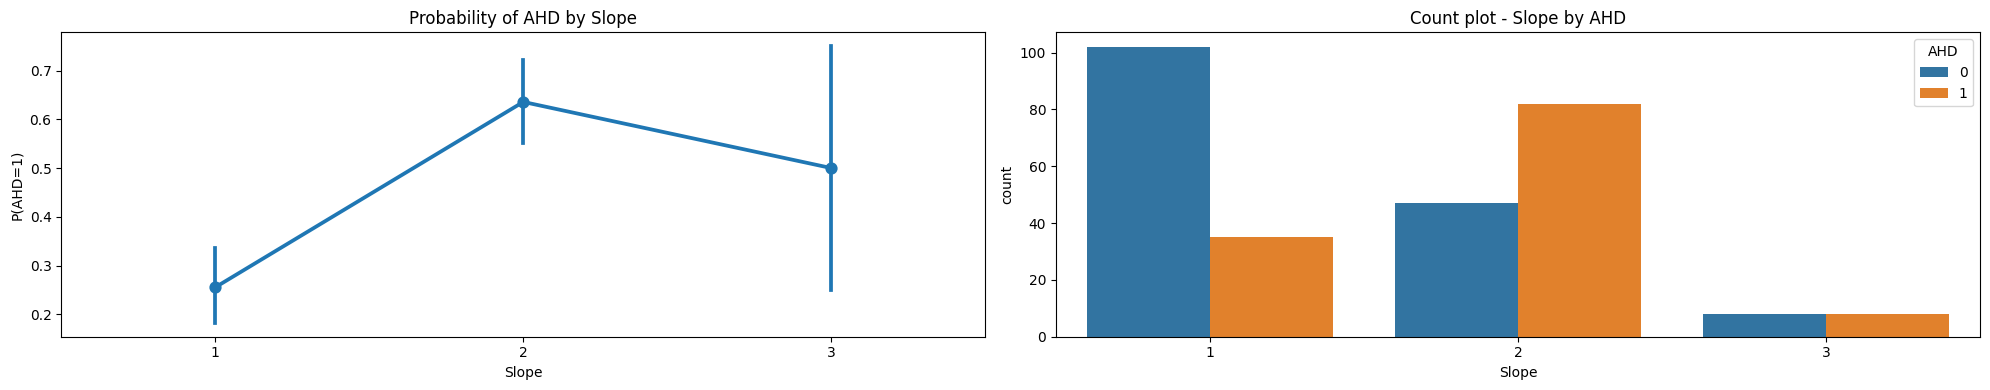

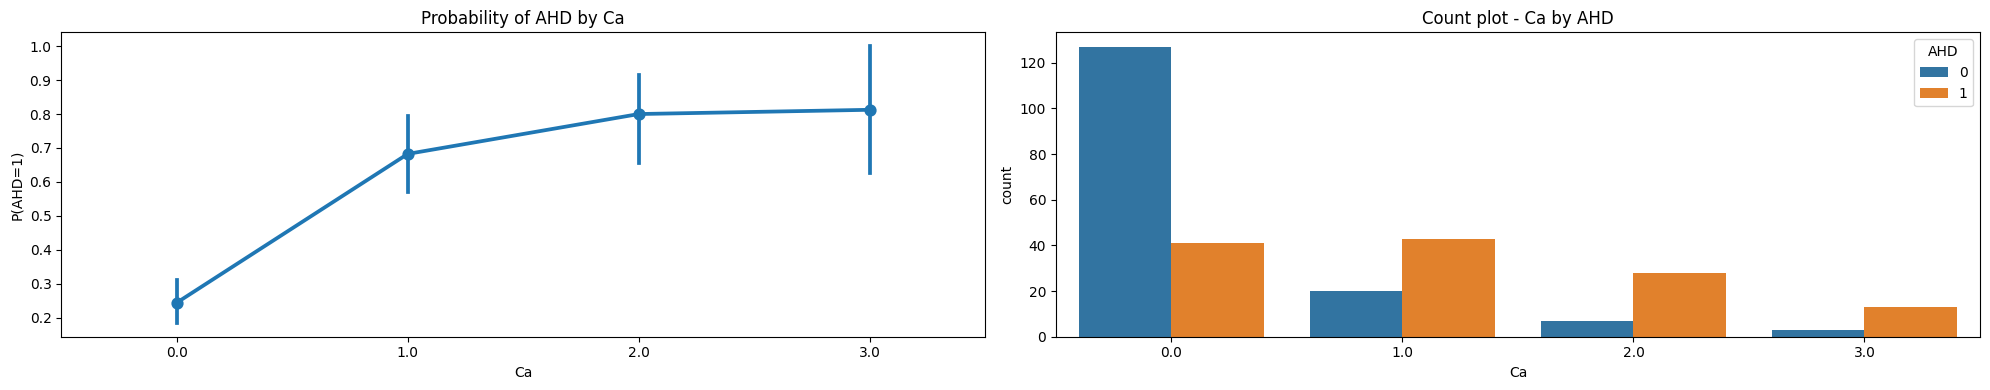

In [70]:
cat_columns_to_plot = df[['RestECG', 'Slope', 'Ca']]
for col in cat_columns_to_plot:
    plot_cat_distributions(df, col)

In [71]:
def plot_binary_features_combined(df, binary_columns, target_col='AHD'):
   
    fig, axes = plt.subplots(1, 2, figsize=(20, 6))
    
    df_melted = pd.melt(df, 
                        id_vars=[target_col], 
                        value_vars=binary_columns,
                        var_name='feature', 
                        value_name='present')
    
    df_present = df_melted[df_melted['present'] == 1]
    
    sns.pointplot(data=df_present, x='feature', y=target_col, 
                  ax=axes[0], capsize=0.2)
    axes[0].set_title('Probability of AHD by Feature', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('P(AHD=1)')
    axes[0].set_xlabel('Feature')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(True, alpha=0.3)
    
    sns.countplot(data=df_present, x='feature', hue=target_col, ax=axes[1])
    axes[1].set_title('Count of Observations by Feature and AHD', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Count')
    axes[1].set_xlabel('Feature')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(title='AHD')
    
    plt.tight_layout()
    plt.show()

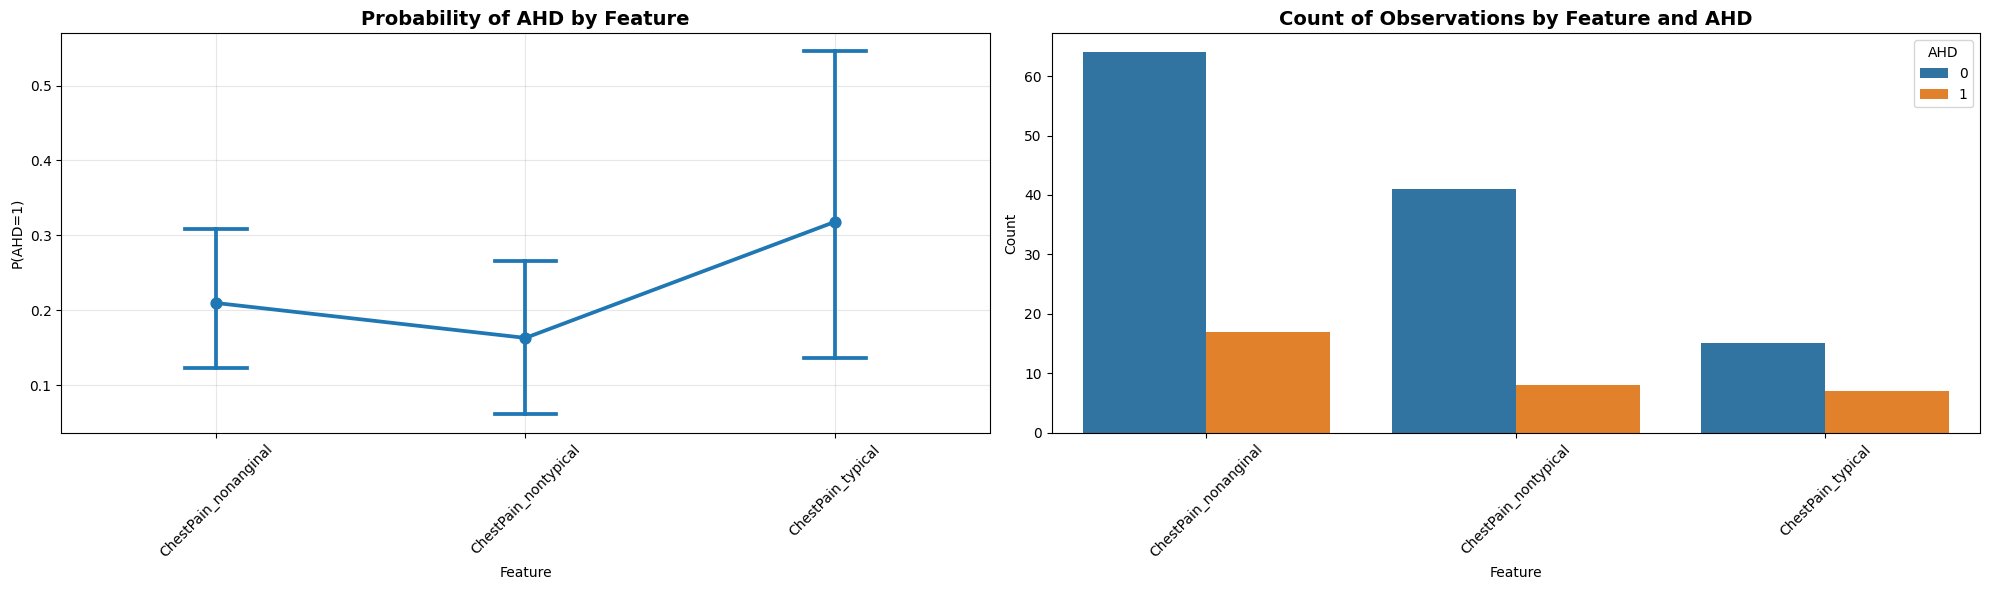

In [72]:
cheat_pain_cols = df[['ChestPain_nonanginal', 'ChestPain_nontypical', 'ChestPain_typical']]
plot_binary_features_combined(df, cheat_pain_cols)

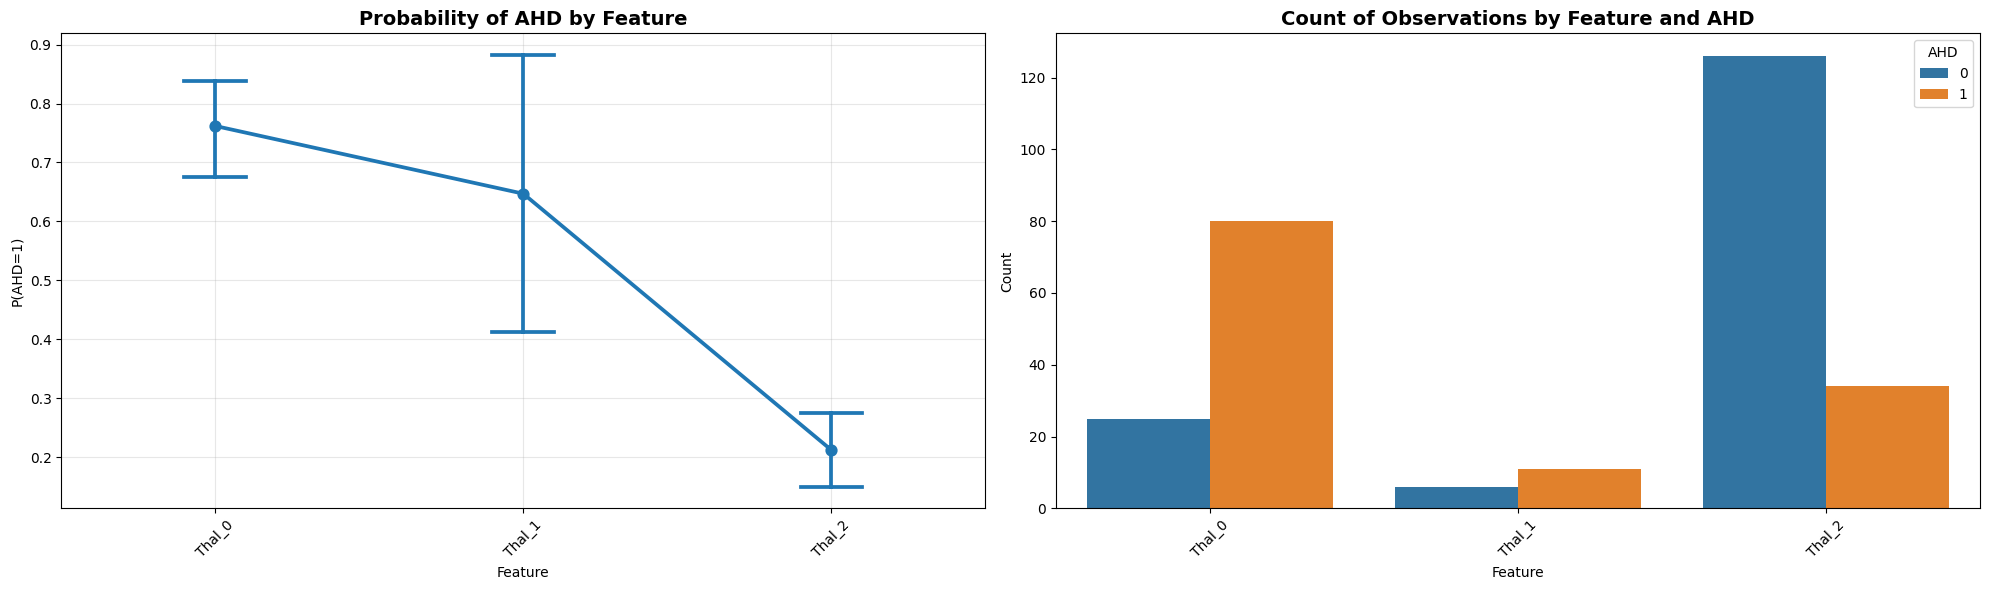

In [73]:
thal_cols = df[['Thal_0', 'Thal_1', 'Thal_2']]
plot_binary_features_combined(df, thal_cols)

Оценим значимость каждого из признаков для целевой переменной. 

In [74]:
X = df.drop(['AHD', 'Diagnosis_binary', 'Unnamed: 0'], axis=1)
y = df['AHD']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

In [75]:
importance_df

,feature,importance
16,Thal_2,0.140649
6,MaxHR,0.122109
8,Oldpeak,0.114672
10,Ca,0.107186
0,Age,0.094893
3,Chol,0.083076
2,RestBP,0.072294
14,Thal_0,0.058961
9,Slope,0.042074
11,ChestPain_nonanginal,0.034615


Получили, что в полученной таблице нет признаков, которые наиболее сильно бы влияли на определение наличие заболевания.

# ИТОГИ.

- Датасет хранит данные о различных обследованиях сердца и наличии у человека заболевания сердца. 
- Ни один из признаков не является определяющим в постановке заболевания. 
- В исходных данных были пропуски, которые были заменены на среднее значение(54.36) для Age, моду(0) для Ca и удалены из таблицы при отсутствии значения в Thal. Такая обработка была выбрана в связи с тем, что возрастные данные достаточно равномерно распределены. Признак Са не является единственным решающим, так как наличие заболевания в данных определяют также признаки пульса, наколона осей на кардиограмме и наличие предшествующих приступов. 
- При этом значения признака Са не только определяют степень тяжести, но и выражают её численно. 
- Для уменьшения числа признаков можно оставить некотрые, которые демонстрируют наиболее яркие отличия в значениях в зависимости от налиция целевого признака: 
Oldpeak(0.59 & 1.58), \
Ca(0.26 & 1.14) \
ExAng(0.14 & 0.54) \
RestECg(0.82 & 1.18) \
Sex(0.56 & 0.81) 

Использование ии: 
- справка по числовым характристикам
- помощь в построении графиков для нескольких колонок в единой структуре